In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from tobii_pytracker.analyze.data_loader import DataLoader
from tobii_pytracker.configs.custom_config import CustomConfig

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from tobii_pytracker.analyze.models import (
    HeatmapAnalyzer,
    FocusMapAnalyzer,
    FixationAnalyzer,
    SaccadeAnalyzer,
    EntropyAnalyzer,
    ClusterAnalyzer,
    ScanpathsAnalyzer,
)


config = CustomConfig('./configs/config.yaml')
loader = DataLoader(config, root='./')

▶ Global heatmap statistics


,avg_gaze_x,avg_gaze_y,gaze_count
0,-188.982587,-1.955224,402


▶ Per-set statistics


,set_name,avg_gaze_x,avg_gaze_y,gaze_count
0,20260915_121735,-188.982587,-1.955224,402


▶ Per-slide statistics


,set_name,slide_index,avg_gaze_x,avg_gaze_y,gaze_count
0,20260915_121735,0,-58.041667,-0.986111,144
1,20260915_121735,1,-228.897638,-1.858268,127
2,20260915_121735,2,-294.221374,-3.114504,131


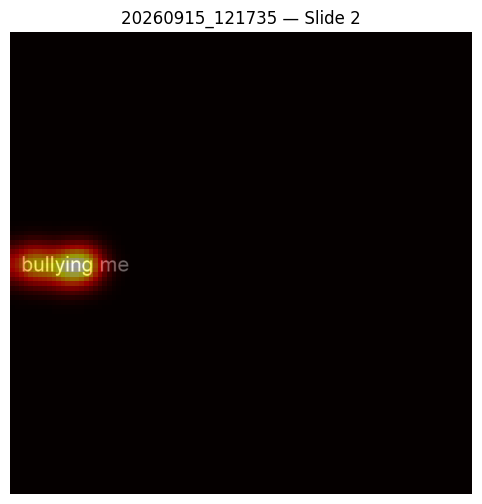

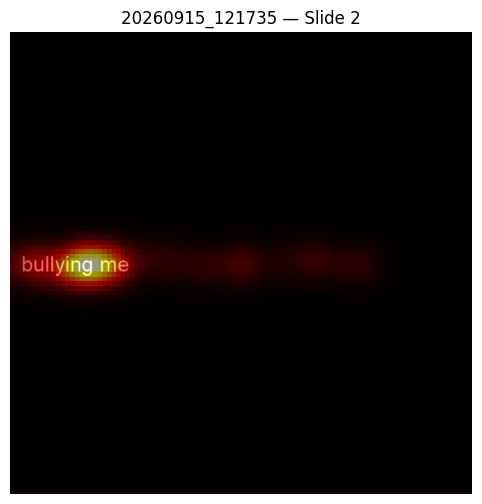

In [3]:
# Assuming you already have the data
background_data = loader.get_all_data(flatten=True)
output_dir = Path("./analysis_outputs")

analyzer = HeatmapAnalyzer(output_folder=output_dir)

# --- Global ---
print("▶ Global heatmap statistics")
global_stats = analyzer.analyze(background_data, per="global")
display(global_stats)

# --- Set-level ---
print("▶ Per-set statistics")
set_stats = analyzer.analyze(background_data, per="set")
display(set_stats.head())

# --- Slide-level ---
print("▶ Per-slide statistics")
slide_stats = analyzer.analyze(background_data, per="slide")
display(slide_stats.head())

# --- Plot heatmap for one image ---
example_slide = background_data.iloc[-1]
subset = background_data[
    (background_data["set_name"] == example_slide["set_name"]) &
    (background_data["slide_index"] == example_slide["slide_index"])
]
screenshot_path = Path(loader.root) / example_slide["screenshot_file"]

analyzer.plot_analysis(
    background_data=subset,
    screenshot_path=screenshot_path,
    title=f"{example_slide['set_name']} — Slide {example_slide['slide_index']}",
)


analyzer.plot_analysis(
    background_data=background_data,
    screenshot_path=screenshot_path,
    title=f"{example_slide['set_name']} — Slide {example_slide['slide_index']}",
)


▶ Global focus map statistics


,avg_gaze_x,avg_gaze_y,gaze_count
0,-188.982587,-1.955224,402


▶ Per-set statistics


,set_name,avg_gaze_x,avg_gaze_y,gaze_count
0,20260915_121735,-188.982587,-1.955224,402


▶ Per-slide statistics


,set_name,slide_index,avg_gaze_x,avg_gaze_y,gaze_count
0,20260915_121735,0,-58.041667,-0.986111,144
1,20260915_121735,1,-228.897638,-1.858268,127
2,20260915_121735,2,-294.221374,-3.114504,131


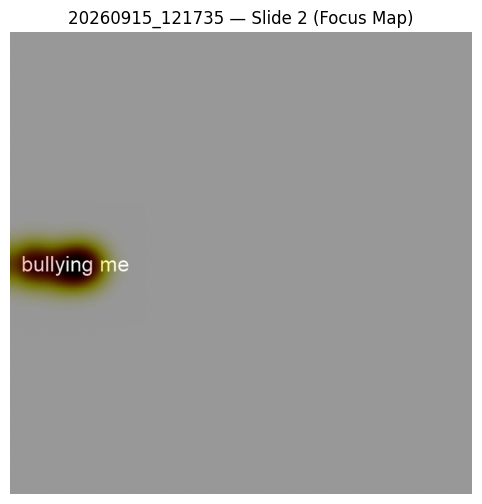

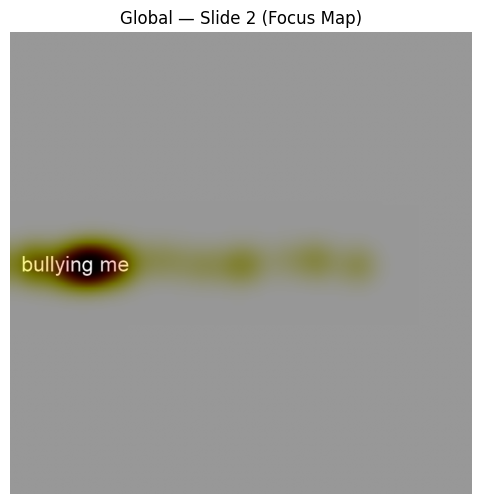

In [4]:
# --- Prepare background data ---
background_data = loader.get_all_data(flatten=True)
output_dir = Path("./analysis_outputs")

analyzer = FocusMapAnalyzer(output_folder=output_dir)

# --- Global ---
print("▶ Global focus map statistics")
global_stats = analyzer.analyze(background_data, per="global")
display(global_stats)

# --- Set-level ---
print("▶ Per-set statistics")
set_stats = analyzer.analyze(background_data, per="set")
display(set_stats.head())

# --- Slide-level ---
print("▶ Per-slide statistics")
slide_stats = analyzer.analyze(background_data, per="slide")
display(slide_stats.head())

# ============================================================
# 🖼 Plot focus map for one example slide
# ============================================================

example_slide = background_data.iloc[-1]
subset = background_data[
    (background_data["set_name"] == example_slide["set_name"]) &
    (background_data["slide_index"] == example_slide["slide_index"])
]
screenshot_path = Path(loader.root) / example_slide["screenshot_file"]

# --- Focus map for single slide (individual subject) ---
analyzer.plot_analysis(
    background_data=subset,
    screenshot_path=screenshot_path,
    title=f"{example_slide['set_name']} — Slide {example_slide['slide_index']} (Focus Map)",
)

# --- Focus map using all gaze data for this slide (across subjects) ---
analyzer.plot_analysis(
    background_data=background_data,
    screenshot_path=screenshot_path,
    title=f"Global — Slide {example_slide['slide_index']} (Focus Map)",
)

▶ Detecting saccades...


,set_name,slide_index,start_time,end_time,duration,x_start,y_start,x_end,y_end,amplitude,peak_velocity,mean_velocity,mean_acceleration
0,20260915_121735,0,15.031390,15.110991,0.099549,-318.0,-3.0,-276.0,-3.0,42.000000,1096.955949,420.541582,20388.654286
1,20260915_121735,0,15.452965,15.452965,0.039271,-271.0,-2.0,-242.0,-1.0,29.017236,738.902954,738.902954,13518.466012
2,20260915_121735,0,15.512166,15.531443,0.039778,-208.0,-1.0,-202.0,-1.0,6.000000,243.894111,147.884836,20459.380127
3,20260915_121735,0,15.733490,15.733490,0.022162,-191.0,1.0,-187.0,1.0,4.000000,180.490754,180.490754,1298.417385
4,20260915_121735,0,15.789793,15.809694,0.055656,-181.0,1.0,-170.0,1.0,11.000000,251.718680,176.105799,4362.458319


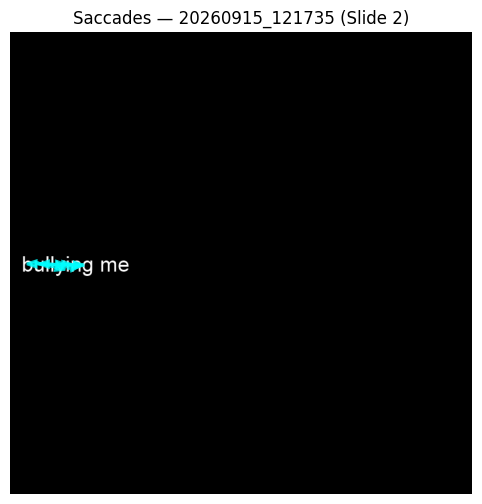

In [5]:
background_data = loader.get_all_data(flatten=True)
output_dir = Path("./analysis_outputs")

saccade_analyzer = SaccadeAnalyzer(
    output_folder=output_dir,
    method="ivt",               # "ivt" (velocity-based) or "acceleration"
    velocity_threshold=120.0,   # pixels/sec
    acceleration_threshold=6000.0,  # pixels/sec^2
    min_duration=0.015,         # seconds
)

print("▶ Detecting saccades...")
saccades = saccade_analyzer.analyze(background_data)
display(saccades.head())

example_slide = background_data.iloc[-1]
screenshot_path = Path(loader.root) / example_slide["screenshot_file"]

saccade_analyzer.plot_analysis(
    saccades=saccades,
    screenshot_path=screenshot_path,
    set_name=example_slide["set_name"],
    slide_index=example_slide["slide_index"],
    title=f"Saccades — {example_slide['set_name']} (Slide {example_slide['slide_index']})",
)

▶ Detecting fixations...


,fix_start,fix_end,duration,x_mean,y_mean,dispersion,set_name,slide_index
0,14.976505,15.452965,0.476460,-282.000000,-2.880000,84.0,20260915_121735,0
1,15.452965,15.754038,0.301074,-200.812500,-0.500000,63.0,20260915_121735,0
2,15.789793,16.093088,0.303296,-140.764706,1.000000,62.0,20260915_121735,0
3,16.114288,16.471197,0.356909,-71.611111,-0.611111,63.0,20260915_121735,0
4,16.491659,16.993775,0.502116,1.814815,-0.333333,65.0,20260915_121735,0


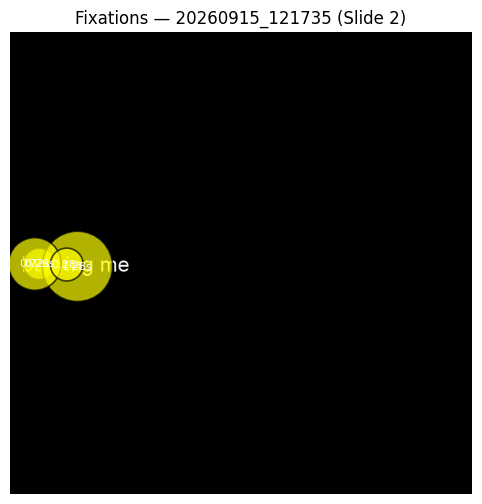

In [6]:
background_data = loader.get_all_data(flatten=True)
output_dir = Path("./analysis_outputs")

fixation_analyzer = FixationAnalyzer(
    output_folder=output_dir,
    method="dispersion",           # or "velocity"
    dispersion_threshold=60.0,     # pixels
    min_duration=0.08,             # seconds
)

print("▶ Detecting fixations...")
fixations = fixation_analyzer.analyze(background_data)
display(fixations.head())

example_slide = background_data.iloc[-1]
screenshot_path = Path(loader.root) / example_slide["screenshot_file"]

fixation_analyzer.plot_analysis(
    fixations=fixations,
    screenshot_path=screenshot_path,
    set_name=example_slide["set_name"],
    slide_index=example_slide["slide_index"],
    title=f"Fixations — {example_slide['set_name']} (Slide {example_slide['slide_index']})",
)

In [7]:
background_data.head()

,set_name,slide_index,screenshot_file,input_data,classification,user_classification,model_prediction,objects_bboxes,voice_file,voice_start_timestamp,...,system_time,gaze_x_left,gaze_y_left,gaze_x_right,gaze_y_right,pupil_left,pupil_right,avg_gaze_x,avg_gaze_y,avg_pupil_size
0,20260915_121735,0,"output\20260915_121735\I`d_have_responded,_.png","I`d have responded, if I were going",neutral,neutral,None,"{'words': [{'word': 'I`d', 'conf': 1.0, 'bbox'...",NaN,NaN,...,14.976505,-324.0,-3.0,None,None,5,0,-324.0,-3.0,2.5
1,20260915_121735,0,"output\20260915_121735\I`d_have_responded,_.png","I`d have responded, if I were going",neutral,neutral,None,"{'words': [{'word': 'I`d', 'conf': 1.0, 'bbox'...",NaN,NaN,...,14.976505,-324.0,-3.0,None,None,5,0,-324.0,-3.0,2.5
2,20260915_121735,0,"output\20260915_121735\I`d_have_responded,_.png","I`d have responded, if I were going",neutral,neutral,None,"{'words': [{'word': 'I`d', 'conf': 1.0, 'bbox'...",NaN,NaN,...,15.011442,-318.0,-3.0,None,None,5,0,-318.0,-3.0,2.5
3,20260915_121735,0,"output\20260915_121735\I`d_have_responded,_.png","I`d have responded, if I were going",neutral,neutral,None,"{'words': [{'word': 'I`d', 'conf': 1.0, 'bbox'...",NaN,NaN,...,15.031390,-311.0,-3.0,None,None,5,0,-311.0,-3.0,2.5
4,20260915_121735,0,"output\20260915_121735\I`d_have_responded,_.png","I`d have responded, if I were going",neutral,neutral,None,"{'words': [{'word': 'I`d', 'conf': 1.0, 'bbox'...",NaN,NaN,...,15.051445,-289.0,-3.0,None,None,5,0,-289.0,-3.0,2.5


▶ Performing gaze clustering...


,set_name,slide_index,screenshot_file,input_data,classification,user_classification,model_prediction,objects_bboxes,voice_file,voice_start_timestamp,...,gaze_x_left,gaze_y_left,gaze_x_right,gaze_y_right,pupil_left,pupil_right,avg_gaze_x,avg_gaze_y,avg_pupil_size,cluster
0,20260915_121735,2,output\20260915_121735\bullying_me.png,bullying me,negative,negative,None,"{'words': [{'word': 'bullying', 'conf': 1.0, '...",NaN,NaN,...,-343.0,2.0,None,None,5,0,-343.0,2.0,2.5,0
1,20260915_121735,2,output\20260915_121735\bullying_me.png,bullying me,negative,negative,None,"{'words': [{'word': 'bullying', 'conf': 1.0, '...",NaN,NaN,...,-343.0,2.0,None,None,5,0,-343.0,2.0,2.5,0
2,20260915_121735,2,output\20260915_121735\bullying_me.png,bullying me,negative,negative,None,"{'words': [{'word': 'bullying', 'conf': 1.0, '...",NaN,NaN,...,-343.0,2.0,None,None,5,0,-343.0,2.0,2.5,0
3,20260915_121735,2,output\20260915_121735\bullying_me.png,bullying me,negative,negative,None,"{'words': [{'word': 'bullying', 'conf': 1.0, '...",NaN,NaN,...,-343.0,2.0,None,None,5,0,-343.0,2.0,2.5,0
4,20260915_121735,2,output\20260915_121735\bullying_me.png,bullying me,negative,negative,None,"{'words': [{'word': 'bullying', 'conf': 1.0, '...",NaN,NaN,...,-343.0,2.0,None,None,5,0,-343.0,2.0,2.5,0


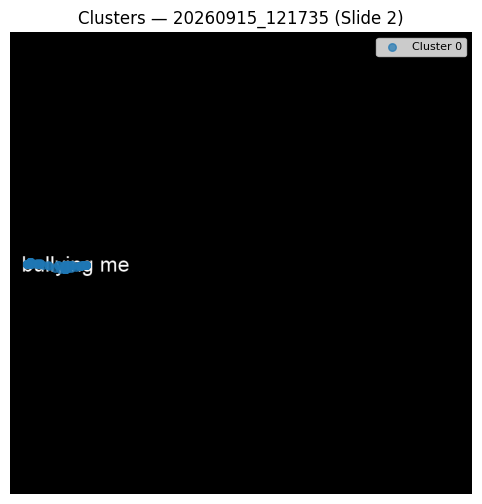

In [8]:
# ==============================================
# 👁️ Cluster Analyzer Demo
# ==============================================
from pathlib import Path
import pandas as pd

#background_data= loader.get_all_data(flatten=True)
background_data= loader.get_slide_data(loader.get_subjects()[-1],-1,flatten=True)
output_dir = Path("./analysis_outputs")

# Instantiate analyzer (DBSCAN by default)
cluster_analyzer = ClusterAnalyzer(
    output_folder=output_dir,
    eps=20,              # pixel distance for clustering
    min_samples=3,        # minimum points per cluster
)

print("▶ Performing gaze clustering...")
clustered_data = cluster_analyzer.analyze(background_data)
display(clustered_data.head())

# --- Visualization for one slide ---
example_slide = background_data.iloc[0]
screenshot_path = Path(loader.root) / example_slide["screenshot_file"]

cluster_analyzer.plot_analysis(
    background_data=clustered_data,
    screenshot_path=screenshot_path,
    set_name=example_slide["set_name"],
    slide_index=example_slide["slide_index"],
    title=f"Clusters — {example_slide['set_name']} (Slide {example_slide['slide_index']})",
)

▶ Slide-level entropy


,entropy,convex_hull_area,num_points,set_name,slide_index
0,5.093747,2761.0,144,20260915_121735,0
1,5.195135,220.5,127,20260915_121735,1
2,4.693134,540.0,131,20260915_121735,2


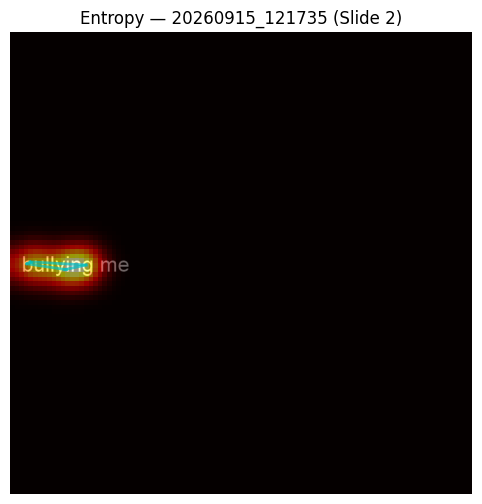

In [9]:
# ==============================================
# 🧠 Entropy Analyzer Demo
# ==============================================
background_data = loader.get_all_data(flatten=True)
output_dir = Path("./analysis_outputs")

entropy_analyzer = EntropyAnalyzer(output_folder=output_dir)

print("▶ Slide-level entropy")
entropy_results = entropy_analyzer.analyze(background_data, per="slide", bins=100, use_convex_hull=True)
display(entropy_results.head())

# --- Visualization for one example slide ---
example_slide = background_data.iloc[-1]
subset = background_data[
    (background_data["set_name"] == example_slide["set_name"]) &
    (background_data["slide_index"] == example_slide["slide_index"])
]
screenshot_path = Path(loader.root) / example_slide["screenshot_file"]

entropy_analyzer.plot_analysis(
    background_data=subset,
    screenshot_path=screenshot_path,
    title=f"Entropy — {example_slide['set_name']} (Slide {example_slide['slide_index']})",
)
